# Data Cleaning

**Purpose:** Load all raw datasets, align them to a common monthly frequency,
clean missing values and outliers

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("husl")

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


# Load Files

In [2]:
# FILE 1: JKM Price
jkm_raw = pd.read_csv('PNGASJPUSDM.csv', encoding='utf-8')

# Always look at raw file first BEFORE setting index
print("=== JKM RAW ===")
print("Shape:", jkm_raw.shape)
print("Columns:", jkm_raw.columns.tolist())
print("Data types:\n", jkm_raw.dtypes)
print("\nFirst 5 rows:")
print(jkm_raw.head())
print("\nLast 5 rows:")
print(jkm_raw.tail())

=== JKM RAW ===
Shape: (411, 2)
Columns: ['observation_date', 'PNGASJPUSDM']
Data types:
 observation_date     object
PNGASJPUSDM         float64
dtype: object

First 5 rows:
  observation_date  PNGASJPUSDM
0       1992-01-01        3.800
1       1992-02-01        3.550
2       1992-03-01        3.450
3       1992-04-01        3.450
4       1992-05-01        3.585

Last 5 rows:
    observation_date  PNGASJPUSDM
406       2025-11-01       11.067
407       2025-12-01        9.910
408       2026-01-01       10.435
409       2026-02-01       10.752
410       2026-03-01       20.812


In [3]:
# Rename columns
jkm_raw.columns = ['date', 'jkm_price']

# Convert date column to datetime format
# errors='coerce' turns unparseable dates into NaT (Not a Time)
jkm_raw['date'] = pd.to_datetime(jkm_raw['date'], errors='coerce')

# Set date as the row index
jkm_raw = jkm_raw.set_index('date')

# Convert price to numeric (sometimes FRED returns '.' for missing — coerce turns it to NaN)
jkm_raw['jkm_price'] = pd.to_numeric(jkm_raw['jkm_price'], errors='coerce')

# Resample to Month Start ('MS') 
jkm = jkm_raw.resample('MS').mean()

# Final check
print("\n=== JKM CLEANED ===")
print("Shape:", jkm.shape)
print("Date range:", jkm.index.min(), "→", jkm.index.max())
print("Missing values:", jkm['jkm_price'].isnull().sum())
print("Price range: ${:.2f} – ${:.2f}/MMBtu".format(
    jkm['jkm_price'].min(), jkm['jkm_price'].max()))
jkm.head()


=== JKM CLEANED ===
Shape: (411, 1)
Date range: 1992-01-01 00:00:00 → 2026-03-01 00:00:00
Missing values: 0
Price range: $2.03 – $54.16/MMBtu


,jkm_price
date,
1992-01-01,3.800
1992-02-01,3.550
1992-03-01,3.450
1992-04-01,3.450
1992-05-01,3.585


In [4]:
# FILE 2: Henry Hub Price (Monthly) 
henry_raw = pd.read_csv('PNGASUSUSDM.csv', encoding='utf-8')

print("=== HENRY HUB RAW ===")
print("Shape:", henry_raw.shape)
print("Columns:", henry_raw.columns.tolist())
henry_raw.head()

=== HENRY HUB RAW ===
Shape: (411, 2)
Columns: ['observation_date', 'PNGASUSUSDM']


,observation_date,PNGASUSUSDM
0,1992-01-01,1.4405
1,1992-02-01,1.1800
2,1992-03-01,1.2600
3,1992-04-01,1.3905
4,1992-05-01,1.5533


In [5]:
# Rename columns
henry_raw.columns = ['date', 'henry_price']

# Convert date column to datetime format
# errors='coerce' turns unparseable dates into NaT (Not a Time)
henry_raw['date'] = pd.to_datetime(henry_raw['date'], errors='coerce')

# Set date as the row index
henry_raw = henry_raw.set_index('date')

# Convert price to numeric (sometimes FRED returns '.' for missing — coerce turns it to NaN)
henry_raw['henry_price'] = pd.to_numeric(henry_raw['henry_price'], errors='coerce')

# Standardise to Month Start index
henry = henry_raw.resample('MS').mean()

print("\n=== HENRY HUB CLEANED ===")
print("Shape:", henry.shape)
print("Date range:", henry.index.min(), "→", henry.index.max())
print("Missing values:", henry['henry_price'].isnull().sum())
print("Price range: ${:.2f} – ${:.2f}/MMBtu".format(
    henry['henry_price'].min(), henry['henry_price'].max()))
henry.head()


=== HENRY HUB CLEANED ===
Shape: (411, 1)
Date range: 1992-01-01 00:00:00 → 2026-03-01 00:00:00
Missing values: 0
Price range: $1.18 – $13.63/MMBtu


,henry_price
date,
1992-01-01,1.4405
1992-02-01,1.1800
1992-03-01,1.2600
1992-04-01,1.3905
1992-05-01,1.5533


In [6]:
# FILE 3: TTF Price
ttf_raw = pd.read_csv('PNGASEUUSDM.csv', encoding='utf-8')

print("=== TTF RAW ===")
print("Shape:", ttf_raw.shape)
print("Columns:", ttf_raw.columns.tolist())
print("Data types:\n", ttf_raw.dtypes)
print("\nFirst 5 rows:")
ttf_raw.head()

=== TTF RAW ===
Shape: (411, 2)
Columns: ['observation_date', 'PNGASEUUSDM']
Data types:
 observation_date     object
PNGASEUUSDM         float64
dtype: object

First 5 rows:


,observation_date,PNGASEUUSDM
0,1992-01-01,2.38
1,1992-02-01,2.38
2,1992-03-01,2.38
3,1992-04-01,2.34
4,1992-05-01,2.34


In [7]:
# Rename columns
ttf_raw.columns = ['date', 'ttf_price']

# Convert date column to datetime format
# errors='coerce' turns unparseable dates into NaT (Not a Time)
ttf_raw['date'] = pd.to_datetime(ttf_raw['date'], errors='coerce')

# Set date as the row index
ttf_raw = ttf_raw.set_index('date')

# Convert price to numeric (sometimes FRED returns '.' for missing — coerce turns it to NaN)
ttf_raw['ttf_price'] = pd.to_numeric(ttf_raw['ttf_price'], errors='coerce')

# Standardise to Month Start index
ttf = ttf_raw.resample('MS').mean()

print("\n=== TTF CLEANED ===")
print("Shape:", ttf.shape)
print("Date range:", ttf.index.min(), "→", ttf.index.max())
print("Missing values:", ttf['ttf_price'].isnull().sum())
print("Price range: ${:.2f} – ${:.2f}/MMBtu".format(
    ttf['ttf_price'].min(), ttf['ttf_price'].max()))
ttf.head()


=== TTF CLEANED ===
Shape: (411, 1)
Date range: 1992-01-01 00:00:00 → 2026-03-01 00:00:00
Missing values: 0
Price range: $1.46 – $69.98/MMBtu


,ttf_price
date,
1992-01-01,2.38
1992-02-01,2.38
1992-03-01,2.38
1992-04-01,2.34
1992-05-01,2.34


In [8]:
# FILE 4: Singapore USEP 
usep_raw = pd.read_csv('Average Monthly USEP.csv', encoding='utf-8')

print("=== USEP RAW ===")
print("Shape:", usep_raw.shape)
print("Columns:", usep_raw.columns.tolist())
print("Data types:\n", usep_raw.dtypes)
print("\nFirst 5 rows:")
usep_raw.head(10)  # Show 10 rows — EMA files sometimes have header rows

=== USEP RAW ===
Shape: (29, 15)
Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14']
Data types:
 Unnamed: 0      object
Unnamed: 1      object
Unnamed: 2      object
Unnamed: 3      object
Unnamed: 4      object
Unnamed: 5      object
Unnamed: 6      object
Unnamed: 7      object
Unnamed: 8      object
Unnamed: 9      object
Unnamed: 10     object
Unnamed: 11     object
Unnamed: 12     object
Unnamed: 13    float64
Unnamed: 14    float64
dtype: object

First 5 rows:


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,Average Monthly Uniform Singapore Energy Price...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unit: Singapore Dollars/MWh,NaN,NaN
2,NaN,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2005,78.6,83.6,97.7,99.8,113.5,113.8,102.8,103.4,147.3,141.6,118.4,117.2,NaN,NaN
5,2006,109.7,106.7,124.3,127.4,155.0,136.1,153.9,167.4,130.2,143.7,117.3,114.2,NaN,NaN
6,2007,123.9,126.9,124.6,114.2,109.8,117.5,124.9,120.4,126.8,126.4,139.6,140.2,NaN,NaN
7,2008,158.1,149.3,147.0,173.4,202.7,185.0,195.0,199.6,193.2,171.8,103.6,67.7,NaN,NaN
8,2009,74.0,95.7,87.2,199.1,167.4,189.6,141.3,161.7,173.2,191.5,142.7,148.0,NaN,NaN
9,2010,171.3,195.6,207.4,162.6,185.3,172.8,147.3,144.2,151.7,162.1,175.1,172.5,NaN,NaN


In [9]:
# Clean the USEP file

usep_raw = pd.read_csv(
    'Average Monthly USEP.csv',
    skiprows=3,          # Skip title, empty, and unit rows — row 4 becomes header
    header=0,            # Row 4 (now row 0) = column headers: blank, Jan, Feb...
    encoding='utf-8-sig' # 'utf-8-sig' handles the BOM character (﻿) at start of file
)

print("=== USEP RAW (after skiprows) ===")
print(usep_raw.shape)
print(usep_raw.columns.tolist())
usep_raw.head(5)

=== USEP RAW (after skiprows) ===
(26, 15)
['Unnamed: 0', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Unnamed: 13', 'Unnamed: 14']


,Unnamed: 0,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Unnamed: 13,Unnamed: 14
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005,78.6,83.6,97.7,99.8,113.5,113.8,102.8,103.4,147.3,141.6,118.4,117.2,NaN,NaN
2,2006,109.7,106.7,124.3,127.4,155.0,136.1,153.9,167.4,130.2,143.7,117.3,114.2,NaN,NaN
3,2007,123.9,126.9,124.6,114.2,109.8,117.5,124.9,120.4,126.8,126.4,139.6,140.2,NaN,NaN
4,2008,158.1,149.3,147.0,173.4,202.7,185.0,195.0,199.6,193.2,171.8,103.6,67.7,NaN,NaN


In [10]:
# Rename the first column (currently blank/unnamed) to 'year'
usep_raw.columns = ['year','Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec','_drop1','_drop2']

# Keep only rows where 'year' is a valid 4-digit year number
usep_raw = usep_raw[pd.to_numeric(usep_raw['year'], errors='coerce').notna()].copy()
usep_raw['year'] = usep_raw['year'].astype(int)

print("Years in data:", usep_raw['year'].tolist())
usep_raw.head()

Years in data: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


,year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,_drop1,_drop2
1,2005,78.6,83.6,97.7,99.8,113.5,113.8,102.8,103.4,147.3,141.6,118.4,117.2,NaN,NaN
2,2006,109.7,106.7,124.3,127.4,155.0,136.1,153.9,167.4,130.2,143.7,117.3,114.2,NaN,NaN
3,2007,123.9,126.9,124.6,114.2,109.8,117.5,124.9,120.4,126.8,126.4,139.6,140.2,NaN,NaN
4,2008,158.1,149.3,147.0,173.4,202.7,185.0,195.0,199.6,193.2,171.8,103.6,67.7,NaN,NaN
5,2009,74.0,95.7,87.2,199.1,167.4,189.6,141.3,161.7,173.2,191.5,142.7,148.0,NaN,NaN


In [11]:
# Wide → Long: melt the 12 month columns into rows
usep_long = usep_raw.melt(
    id_vars=['year'],
    value_vars=['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec'],
    var_name='month_str',
    value_name='USEP'
)

# Map month abbreviation to number
month_map = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,
             'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}
usep_long['month_num'] = usep_long['month_str'].map(month_map)

# Build a proper datetime column — Day 1 of each month
usep_long['date'] = pd.to_datetime(
    usep_long['year'].astype(str) + '-' +
    usep_long['month_num'].astype(str).str.zfill(2) + '-01'
)

# Convert price to numeric (2026 partial year will have NaN for May–Dec — that's correct)
usep_long['USEP'] = pd.to_numeric(usep_long['USEP'], errors='coerce')

# Drop the empty future months (NaN prices)
usep_long = usep_long.dropna(subset=['USEP'])

# Set date as index, sort chronologically, keep only the two columns we need
usep = usep_long[['date', 'USEP']].set_index('date').sort_index()
usep = usep.resample('MS').mean()   # Standardise index to Month Start

print("=== USEP CLEANED ===")
print("Shape:", usep.shape)
print("Date range:", usep.index.min(), "→", usep.index.max())
print("Missing values:", usep['USEP'].isnull().sum())
print("Price range: {:.1f} – {:.1f} SGD/MWh".format(
    usep['USEP'].min(), usep['USEP'].max()))
usep.head(12)

=== USEP CLEANED ===
Shape: (256, 1)
Date range: 2005-01-01 00:00:00 → 2026-04-01 00:00:00
Missing values: 0
Price range: 43.6 – 492.1 SGD/MWh


,USEP
date,
2005-01-01,78.6
2005-02-01,83.6
2005-03-01,97.7
2005-04-01,99.8
2005-05-01,113.5
2005-06-01,113.8
2005-07-01,102.8
2005-08-01,103.4
2005-09-01,147.3


In [12]:
# FILE 5: LNG-T3 Trade Flows 
print("Loading LNG-T3 trade data (this may take 30–60 seconds)...")

trade_raw = pd.read_csv('LNG_trade_daily.csv', encoding='utf-8',
                        low_memory=False)  # low_memory=False prevents mixed type warnings

print("=== LNG-T3 TRADE RAW ===")
print("Shape:", trade_raw.shape)
print("Columns:", trade_raw.columns.tolist())
print("Data types:\n", trade_raw.dtypes)
print("\nFirst 5 rows:")
print(trade_raw.head())
print("\nUnique 'to_country' values (sample):")
print(trade_raw['to_country'].unique()[:20])

Loading LNG-T3 trade data (this may take 30–60 seconds)...
=== LNG-T3 TRADE RAW ===
Shape: (16691, 7)
Columns: ['date', 'type', 'from_country', 'to_country', 'amount_cmb', 'voyage_distance', 'confidence_score']
Data types:
 date                 object
type                 object
from_country         object
to_country           object
amount_cmb            int64
voyage_distance     float64
confidence_score    float64
dtype: object

First 5 rows:
         date     type   from_country      to_country  amount_cmb  \
0  2020-01-07  arrival         Norway          Sweden       18000   
1  2020-01-08  arrival         Norway  United Kingdom      166686   
2  2020-01-10  arrival        Algeria          France       75500   
3  2020-01-11  arrival         Russia           Spain      172000   
4  2020-01-12  arrival  United States        Portugal      160000   

   voyage_distance  confidence_score  
0            468.0               4.0  
1           2838.0               4.0  
2           1032.0 

In [13]:
# Find all entries that contain 'singapore' (case-insensitive)
sg_matches = [c for c in trade_raw['to_country'].unique()
              if 'singapore' in str(c).lower()]

print("Singapore-related entries found:", sg_matches)

Singapore-related entries found: []


In [14]:
# Print All Unique Countries to Find the Right Name
print(trade_raw['to_country'].value_counts().to_string())

to_country
China                   1768
France                  1679
Japan                   1589
Spain                   1417
South Korea             1193
Belgium                  981
United Kingdom           919
Netherlands              818
India                    679
Taiwan                   653
Türkiye                  618
Pakistan                 433
Thailand                 430
Kuwait                   416
Portugal                 416
Poland                   267
Italy                    259
Finland                  204
Croatia                  184
Lithuania                184
Sweden                   180
United Arab Emirates     155
Indonesia                151
Chile                    148
Gibraltar                147
Malaysia                 136
Greece                   122
United States            118
Germany                   87
Brazil                    66
Hong Kong                 58
Jamaica                   34
Colombia                  32
Norway                    26
Mex

In [15]:
#  Also Check the from_country Column
print("All columns:")
print(trade_raw.columns.tolist())
print("\nFirst 3 rows:")
print(trade_raw.head(3))

All columns:
['date', 'type', 'from_country', 'to_country', 'amount_cmb', 'voyage_distance', 'confidence_score']

First 3 rows:
         date     type from_country      to_country  amount_cmb  \
0  2020-01-07  arrival       Norway          Sweden       18000   
1  2020-01-08  arrival       Norway  United Kingdom      166686   
2  2020-01-10  arrival      Algeria          France       75500   

   voyage_distance  confidence_score  
0            468.0               4.0  
1           2838.0               4.0  
2           1032.0               4.0  


In [16]:
print(trade_raw['from_country'].value_counts().to_string())

from_country
United States           4038
Qatar                   3811
Russia                  2607
Australia               2088
Nigeria                 1227
Algeria                  994
Norway                   415
United Arab Emirates     377
Trinidad and Tobago      344
Egypt                    207
Malaysia                 164
Equatorial Guinea        118
Oman                     112
Cameroon                  78
Turkmenistan              55
Indonesia                 28
Peru                      26
Mozambique                 2


In [17]:
# Singapore Energy Statistics: PNG and LNG Import Volumes - Replacement for LNG Trade Flows file

ses_raw = pd.read_csv(
    'SG_LNG_PNG_import.csv',
    skiprows=3,           # Skip navigation row, title row, unit row
    header=0,             # Row 4 becomes header: 'Energy Products', 2005, 2006...
    encoding='utf-8-sig'  # Handles BOM character at start of file
)

print("=== SES RAW ===")
print(ses_raw.shape)
print(ses_raw.iloc[:, 0].tolist())  # Print all row labels to confirm exact names

=== SES RAW ===
(37, 21)
[nan, 'Total', nan, 'Coal and Peat', nan, 'Crude Oil', '     Crude Oil', '     Other Crude Oil', nan, 'Petroleum Products', '     Fuel Oil', '     Gas/ Diesel Oil', '     Gasoline', '     Crude Oil', '     Naphtha', '     Other Petroleum Products', nan, 'Natural Gas (NG)', '     Pipeline NG', '     Liquefied NG', nan, 'Other Energy Products', nan, nan, nan, 'Notes:', 'a. Numbers may not add up to the totals due to rounding.', "b. All data are compiled from Enterprise Singapore's trade statistics except Natural Gas, Other Energy Products and biomass trade data, which are compiled from EMA's administrative returns.", 'c. Enterprise Singapore releases trade data in mass units. EMA releases similar data in energy units (ktoe).', "d. The product classification of energy products aligns with International Energy Agency's (IEA) classification and may differ from that used for trade statistics.", 'e. The data compiled in this table were based on AHTN 2022.', 'f. Biomas

In [18]:
# Rename the first column
ses_raw.columns = ['energy_product'] + [str(y) for y in range(2005, 2025)]

# Strip whitespace from product names (EMA uses leading spaces for sub-rows)
ses_raw['energy_product'] = ses_raw['energy_product'].str.strip()

print("Unique energy product labels:")
print(ses_raw['energy_product'].tolist())

Unique energy product labels:
[nan, 'Total', nan, 'Coal and Peat', nan, 'Crude Oil', 'Crude Oil', 'Other Crude Oil', nan, 'Petroleum Products', 'Fuel Oil', 'Gas/ Diesel Oil', 'Gasoline', 'Crude Oil', 'Naphtha', 'Other Petroleum Products', nan, 'Natural Gas (NG)', 'Pipeline NG', 'Liquefied NG', nan, 'Other Energy Products', nan, nan, nan, 'Notes:', 'a. Numbers may not add up to the totals due to rounding.', "b. All data are compiled from Enterprise Singapore's trade statistics except Natural Gas, Other Energy Products and biomass trade data, which are compiled from EMA's administrative returns.", 'c. Enterprise Singapore releases trade data in mass units. EMA releases similar data in energy units (ktoe).', "d. The product classification of energy products aligns with International Energy Agency's (IEA) classification and may differ from that used for trade statistics.", 'e. The data compiled in this table were based on AHTN 2022.', 'f. Biomass trade recorded is for energy use only.', na

In [19]:
# Extract the two rows required
png_row = ses_raw[ses_raw['energy_product'] == 'Pipeline NG'].copy()
lng_row = ses_raw[ses_raw['energy_product'] == 'Liquefied NG'].copy()

print("PNG row found:", len(png_row), "rows")
print("LNG row found:", len(lng_row), "rows")
print(png_row)
print(lng_row)

PNG row found: 1 rows
LNG row found: 1 rows
   energy_product       2005       2006       2007       2008       2009  \
18    Pipeline NG   5,571.1    6,007.3    6,433.9    6,585.7    6,656.7    

         2010       2011       2012       2013  ...       2015       2016  \
18   7,214.5    7,286.8    7,901.6    7,947.8   ...   7,133.6    7,418.6    

         2017       2018       2019       2020       2021       2022  \
18   7,143.4    7,109.4    6,571.7    6,678.9    7,378.5    6,418.9    

         2023       2024  
18   5,169.2    4,804.9   

[1 rows x 21 columns]
   energy_product   2005   2006   2007   2008   2009   2010   2011   2012  \
19   Liquefied NG   -      -      -      -      -      -      -      -      

       2013  ...       2015       2016       2017       2018       2019  \
19   948.3   ...   2,319.9    2,261.9    2,728.4    2,850.0    3,575.9    

         2020       2021       2022       2023       2024  
19   3,529.7    3,246.1    4,123.2    5,402.1    6,104.6   


In [20]:
# Wide → Long conversion 
year_cols = [str(y) for y in range(2005, 2025)]

def wide_to_long(row_df, value_name):
    """Melt a single wide-format row into a long time series."""
    melted = row_df.melt(
        id_vars=['energy_product'],
        value_vars=year_cols,
        var_name='year',
        value_name=value_name
    )
    # Build date as Jan 1 of each year (annual data — no monthly breakdown available)
    melted['date'] = pd.to_datetime(melted['year'] + '-01-01')
    
    # Clean the value column: remove commas, spaces, convert '-' to NaN
    melted[value_name] = melted[value_name].astype(str).str.replace(',', '').str.strip()
    melted[value_name] = melted[value_name].replace('-', np.nan)
    melted[value_name] = melted[value_name].replace(' -  ', np.nan)
    melted[value_name] = pd.to_numeric(melted[value_name], errors='coerce')
    
    return melted[['date', value_name]].set_index('date').sort_index()

png_clean = wide_to_long(png_row, 'png_import_ktoe')
lng_clean = wide_to_long(lng_row, 'lng_import_ktoe')

print("=== PNG CLEANED ===")
print(png_clean)
print("\n=== LNG CLEANED ===")
print(lng_clean)

=== PNG CLEANED ===
            png_import_ktoe
date                       
2005-01-01           5571.1
2006-01-01           6007.3
2007-01-01           6433.9
2008-01-01           6585.7
2009-01-01           6656.7
2010-01-01           7214.5
2011-01-01           7286.8
2012-01-01           7901.6
2013-01-01           7947.8
2014-01-01           7384.5
2015-01-01           7133.6
2016-01-01           7418.6
2017-01-01           7143.4
2018-01-01           7109.4
2019-01-01           6571.7
2020-01-01           6678.9
2021-01-01           7378.5
2022-01-01           6418.9
2023-01-01           5169.2
2024-01-01           4804.9

=== LNG CLEANED ===
            lng_import_ktoe
date                       
2005-01-01              NaN
2006-01-01              NaN
2007-01-01              NaN
2008-01-01              NaN
2009-01-01              NaN
2010-01-01              NaN
2011-01-01              NaN
2012-01-01              NaN
2013-01-01            948.3
2014-01-01           2033.3
2015-01

In [21]:
# Merge PNG and LNG into one DataFrame 
gas_imports = pd.concat([png_clean, lng_clean], axis=1)

# LNG was zero/nil before 2013 (SLNG terminal opened) — fill with 0, not NaN
gas_imports['lng_import_ktoe'] = gas_imports['lng_import_ktoe'].fillna(0)

print("=== GAS IMPORTS (Annual) ===")
print(gas_imports)
print("\nMissing values:", gas_imports.isnull().sum().to_dict())

=== GAS IMPORTS (Annual) ===
            png_import_ktoe  lng_import_ktoe
date                                        
2005-01-01           5571.1              0.0
2006-01-01           6007.3              0.0
2007-01-01           6433.9              0.0
2008-01-01           6585.7              0.0
2009-01-01           6656.7              0.0
2010-01-01           7214.5              0.0
2011-01-01           7286.8              0.0
2012-01-01           7901.6              0.0
2013-01-01           7947.8            948.3
2014-01-01           7384.5           2033.3
2015-01-01           7133.6           2319.9
2016-01-01           7418.6           2261.9
2017-01-01           7143.4           2728.4
2018-01-01           7109.4           2850.0
2019-01-01           6571.7           3575.9
2020-01-01           6678.9           3529.7
2021-01-01           7378.5           3246.1
2022-01-01           6418.9           4123.2
2023-01-01           5169.2           5402.1
2024-01-01           4804.

**SES Gas Imports (EMA):**
- Unit: ktoe (kilotonne of oil equivalent) — annual frequency only, no monthly breakdown
- PNG (Pipeline NG): Malaysia/Indonesia pipeline gas; declining since 2017 as contracts expire
- LNG (Liquefied NG): Starts 2013 when SLNG terminal opened; overtook PNG volumes in ~2023
- LNG values before 2013 are nil ("-") in source — treated as 0 in cleaning
- Source: Enterprise Singapore trade stats + EMA administrative returns [file:193]

The EMA file contains annual data for PNG and LNG imports (e.g., Singapore imported 6,105 ktoe of LNG in 2024). The master DataFrame has monthly rows — one row per month from 2005 to 2026. It is not possible to merge an annual number into a monthly table without breaking it into 12 monthly estimates first.

Assumption: Singapore's gas demand is not flat across the year — it follows a seasonal pattern driven by temperature and industrial activity. Use known seasonal weights derived from Singapore's electricity consumption patterns to distribute the annual total more realistically.



In [22]:
# ── Calculate Seasonal Weights from EMA Electricity Consumption Data ─────────
# Source: SG Monthly Electricity Consumption.csv (EMA, Singapore)
# Method: For each year, compute each month's share of annual total.
#         Average across all complete years (2005-2024). Normalise to sum=1.

import pandas as pd
import numpy as np

# ── Step 1: Load the raw file ─────────────────────────────────────────────────
ses_raw = pd.read_csv(
    'SG Monthly Electricity Consumption.csv',
    header=None,
    encoding='utf-8-sig'
)

print("Raw shape:", ses_raw.shape)
print(ses_raw.iloc[:6, :5])  # Preview top-left corner

Raw shape: (367, 14)
                                                   0    1    2    3    4
0                                                NaN  NaN  NaN  NaN  NaN
1  Total Household Electricity Consumption by Dwe...  NaN  NaN  NaN  NaN
2                                                NaN  NaN  NaN  NaN  NaN
3                                               2005  NaN  NaN  NaN  NaN
4                                                NaN  Jan  Feb  Mar  Apr
5                                                NaN  NaN  NaN  NaN  NaN


In [23]:
# ── Step 2: Extract only the 'Overall' rows for each year ────────────────────
# The file repeats this pattern every ~9 rows:
#   Row 0: Year label (e.g., "2005")
#   Row 1: Month headers (Jan, Feb, ... Dec, Annual)
#   Row 2: blank
#   Row 3: Overall  <-- this is the row we want
#   Rows 4-8: sub-categories (Public Housing, Private, etc.)

month_cols = ['Jan','Feb','Mar','Apr','May','Jun',
              'Jul','Aug','Sep','Oct','Nov','Dec']

records = []

for i, row in ses_raw.iterrows():
    first_cell = str(row.iloc[0]).strip()

    # Detect year rows (4-digit number between 2005 and 2024)
    if first_cell.isdigit() and 2005 <= int(first_cell) <= 2024:
        current_year = int(first_cell)

    # Detect 'Overall' row — this is 2-3 rows after the year label
    if str(row.iloc[0]).strip() == 'Overall':
        values = row.iloc[1:13].tolist()  # Jan through Dec (columns 1-12)
        try:
            monthly = [float(str(v).replace(',','').strip()) for v in values]
            records.append({'year': current_year, **dict(zip(month_cols, monthly))})
        except Exception as e:
            print(f"Skipped year {current_year}: {e}")

elec_df = pd.DataFrame(records).drop_duplicates(subset='year').sort_values('year')

print("\n=== Extracted Overall Electricity Consumption (GWh) ===")
print(elec_df.to_string(index=False))


=== Extracted Overall Electricity Consumption (GWh) ===
 year   Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov   Dec
 2005 447.8 437.1 479.7 533.6 535.0 560.2 537.4 528.8 516.3 520.0 518.6 478.0
 2006 465.5 452.3 470.0 511.3 522.0 533.2 513.2 544.2 541.4 525.7 535.2 495.0
 2007 473.6 444.4 451.8 511.0 542.8 556.0 563.1 555.0 513.6 514.7 547.9 489.9
 2008 467.1 472.7 449.5 491.5 544.0 572.5 525.8 510.1 519.1 522.1 535.6 484.0
 2009 476.4 460.5 461.2 510.5 556.6 609.5 592.7 572.1 554.9 557.4 562.9 516.0
 2010 490.6 503.9 547.6 585.0 573.5 606.0 575.2 539.7 539.2 557.8 581.4 536.2
 2011 499.3 461.7 465.7 524.4 565.1 602.8 586.0 590.6 582.6 557.7 541.1 505.9
 2012 503.3 505.0 508.6 540.9 557.1 607.9 594.8 585.6 573.2 560.2 568.1 524.8
 2013 513.1 498.0 498.3 568.3 601.8 629.6 612.0 617.5 560.6 555.0 570.7 530.1
 2014 509.7 489.3 488.7 568.1 609.5 639.0 628.1 635.5 592.4 580.9 611.5 571.8
 2015 525.2 493.6 513.9 594.2 610.7 632.3 647.0 656.7 635.7 643.6 645.7 622.4
 2016 5

In [24]:
# ── Step 3: Calculate each month's share of the annual total (per year) ───────
elec_df['annual_total'] = elec_df[month_cols].sum(axis=1)

for m in month_cols:
    elec_df[f'w_{m}'] = elec_df[m] / elec_df['annual_total']

# Quick check — each row's weights should sum to 1.0
weight_cols = [f'w_{m}' for m in month_cols]
elec_df['weight_sum'] = elec_df[weight_cols].sum(axis=1)
print("\nWeight row sums (all should be 1.0):")
print(elec_df[['year','weight_sum']].to_string(index=False))


Weight row sums (all should be 1.0):
 year  weight_sum
 2005         1.0
 2006         1.0
 2007         1.0
 2008         1.0
 2009         1.0
 2010         1.0
 2011         1.0
 2012         1.0
 2013         1.0
 2014         1.0
 2015         1.0
 2016         1.0
 2017         1.0
 2018         1.0
 2019         1.0
 2020         1.0
 2021         1.0
 2022         1.0
 2023         1.0
 2024         1.0


In [25]:
# ── Step 4: Average weights across all years, then normalise ──────────────────
mean_weights = elec_df[weight_cols].mean()
mean_weights.index = month_cols   # Rename index from 'w_Jan' → 'Jan'

# Normalise to ensure exact sum = 1.0 (removes floating point drift)
mean_weights = mean_weights / mean_weights.sum()

# ── Step 5: Print results ─────────────────────────────────────────────────────
print("\n=== FINAL SEASONAL WEIGHTS ===")
print("Derived from EMA Household Electricity Consumption, 2005-2024\n")
for m, w in mean_weights.items():
    bar = '█' * int(w * 200)   # Visual bar proportional to weight
    print(f"  {m}: {w:.6f} ({w*100:.2f}%)  {bar}")

print(f"\nSum of weights: {mean_weights.sum():.10f}")
print(f"Highest demand month: {mean_weights.idxmax()} ({mean_weights.max()*100:.2f}%)")
print(f"Lowest demand month:  {mean_weights.idxmin()} ({mean_weights.min()*100:.2f}%)")


=== FINAL SEASONAL WEIGHTS ===
Derived from EMA Household Electricity Consumption, 2005-2024

  Jan: 0.075270 (7.53%)  ███████████████
  Feb: 0.074151 (7.42%)  ██████████████
  Mar: 0.074793 (7.48%)  ██████████████
  Apr: 0.083196 (8.32%)  ████████████████
  May: 0.087087 (8.71%)  █████████████████
  Jun: 0.092252 (9.23%)  ██████████████████
  Jul: 0.089321 (8.93%)  █████████████████
  Aug: 0.087887 (8.79%)  █████████████████
  Sep: 0.085751 (8.58%)  █████████████████
  Oct: 0.084901 (8.49%)  ████████████████
  Nov: 0.085699 (8.57%)  █████████████████
  Dec: 0.079691 (7.97%)  ███████████████

Sum of weights: 1.0000000000
Highest demand month: Jun (9.23%)
Lowest demand month:  Feb (7.42%)


In [26]:
# ── Step 6: Build the final dict and verify ───────────────────────────────────
SEASONAL_WEIGHTS = {i+1: round(w, 6) for i, w in enumerate(mean_weights)}

print("\n=== COPY THIS INTO YOUR NOTEBOOK ===")
print("SEASONAL_WEIGHTS = {")
for month_num, w in SEASONAL_WEIGHTS.items():
    m_name = month_cols[month_num - 1]
    print(f"    {month_num:2d}: {w},   # {m_name}")
print("}")

# Final assertion
assert abs(sum(SEASONAL_WEIGHTS.values()) - 1.0) < 0.001, "Weights don't sum to 1!"
print("\n✅ Weights verified — ready to use in annual_to_monthly_seasonal()")


=== COPY THIS INTO YOUR NOTEBOOK ===
SEASONAL_WEIGHTS = {
     1: 0.07527,   # Jan
     2: 0.074151,   # Feb
     3: 0.074793,   # Mar
     4: 0.083196,   # Apr
     5: 0.087087,   # May
     6: 0.092252,   # Jun
     7: 0.089321,   # Jul
     8: 0.087887,   # Aug
     9: 0.085751,   # Sep
    10: 0.084901,   # Oct
    11: 0.085699,   # Nov
    12: 0.079691,   # Dec
}

✅ Weights verified — ready to use in annual_to_monthly_seasonal()


In [27]:
# Define seasonal weights
# Each value = fraction of annual total assigned to that month
# These reflect Singapore's electricity/gas demand seasonality
# Source: derived from EMA monthly electricity consumption patterns

SEASONAL_WEIGHTS = {
     1: 0.07527,   # Jan
     2: 0.074151,   # Feb
     3: 0.074793,   # Mar
     4: 0.083196,   # Apr
     5: 0.087087,   # May
     6: 0.092252,   # Jun
     7: 0.089321,   # Jul
     8: 0.087887,   # Aug
     9: 0.085751,   # Sep
    10: 0.084901,   # Oct
    11: 0.085699,   # Nov
    12: 0.079691,   # Dec
}

# ── Verification: weights must sum to exactly 1.0 ────────────────────────────
# This is a hard requirement — if they don't sum to 1, your monthly totals
# will not equal your annual totals, which is a data integrity error
total_weight = sum(SEASONAL_WEIGHTS.values())
print(f"Sum of all weights: {total_weight:.4f}")
assert abs(total_weight - 1.0) < 0.001, "ERROR: Weights must sum to 1.0"
print("✅ Weights verified — sum to 1.0")

Sum of all weights: 1.0000
✅ Weights verified — sum to 1.0


In [28]:
# ── Step 2: Define the disaggregation function ───────────────────────────────

def annual_to_monthly_seasonal(annual_df, value_col):
    """
    Converts an annual time series to monthly estimates using seasonal weights.

    Purpose: Distribute annual totals across 12 months in proportion to
    Singapore's typical seasonal demand pattern — more realistic than
    dividing equally.

    Parameters:
        annual_df  : DataFrame with DatetimeIndex (Jan 1 of each year)
        value_col  : Name of the column containing annual values

    Returns:
        DataFrame with monthly DatetimeIndex and disaggregated monthly values
    """
    monthly_rows = []   # Will collect one dictionary per month

    for year_date, row in annual_df.iterrows():
        annual_value = row[value_col]

        # Skip years where annual value is missing or zero
        if pd.isna(annual_value):
            continue

        # Loop through all 12 months and apply the weight
        for month_num, weight in SEASONAL_WEIGHTS.items():

            monthly_value = annual_value * weight   # This month's share

            monthly_rows.append({
                'date':    pd.Timestamp(year=year_date.year,
                                        month=month_num, day=1),
                value_col: round(monthly_value, 2)
            })

    # Convert list of dicts to DataFrame
    result = pd.DataFrame(monthly_rows)
    result = result.set_index('date').sort_index()

    return result

In [29]:
# ── Step 3: Apply the function to both series ────────────────────────────────

png_monthly = annual_to_monthly_seasonal(png_clean, 'png_import_ktoe')
lng_monthly = annual_to_monthly_seasonal(lng_clean, 'lng_import_ktoe')

print("PNG monthly shape:", png_monthly.shape)
print("LNG monthly shape:", lng_monthly.shape)
print("\nFirst 14 rows of PNG (first 2 years):")
print(png_monthly.head(14))

PNG monthly shape: (240, 1)
LNG monthly shape: (144, 1)

First 14 rows of PNG (first 2 years):
            png_import_ktoe
date                       
2005-01-01           419.34
2005-02-01           413.10
2005-03-01           416.68
2005-04-01           463.49
2005-05-01           485.17
2005-06-01           513.95
2005-07-01           497.62
2005-08-01           489.63
2005-09-01           477.73
2005-10-01           472.99
2005-11-01           477.44
2005-12-01           443.97
2006-01-01           452.17
2006-02-01           445.45


In [30]:
# ── Step 4: Sanity check — re-aggregate monthly back to annual ───────────────
# Resample monthly → annual sum and compare to original annual values

png_annual_check = png_monthly.resample('YS').sum()
lng_annual_check = lng_monthly.resample('YS').sum()

print("=== PNG: Original Annual vs Re-aggregated Monthly Sum ===")
comparison_png = pd.concat([
    png_clean.rename(columns={'png_import_ktoe': 'original_annual'}),
    png_annual_check.rename(columns={'png_import_ktoe': 'sum_of_monthly'})
], axis=1)
comparison_png['difference'] = (
    comparison_png['sum_of_monthly'] - comparison_png['original_annual']
).round(2)
print(comparison_png)

print("\n=== LNG: Original Annual vs Re-aggregated Monthly Sum ===")
comparison_lng = pd.concat([
    lng_clean.rename(columns={'lng_import_ktoe': 'original_annual'}),
    lng_annual_check.rename(columns={'lng_import_ktoe': 'sum_of_monthly'})
], axis=1)
comparison_lng['difference'] = (
    comparison_lng['sum_of_monthly'] - comparison_lng['original_annual']
).round(2)
print(comparison_lng)

=== PNG: Original Annual vs Re-aggregated Monthly Sum ===
            original_annual  sum_of_monthly  difference
date                                                   
2005-01-01           5571.1         5571.11        0.01
2006-01-01           6007.3         6007.30        0.00
2007-01-01           6433.9         6433.88       -0.02
2008-01-01           6585.7         6585.69       -0.01
2009-01-01           6656.7         6656.68       -0.02
2010-01-01           7214.5         7214.50        0.00
2011-01-01           7286.8         7286.78       -0.02
2012-01-01           7901.6         7901.59       -0.01
2013-01-01           7947.8         7947.81        0.01
2014-01-01           7384.5         7384.48       -0.02
2015-01-01           7133.6         7133.58       -0.02
2016-01-01           7418.6         7418.61        0.01
2017-01-01           7143.4         7143.38       -0.02
2018-01-01           7109.4         7109.40        0.00
2019-01-01           6571.7         6571.70   

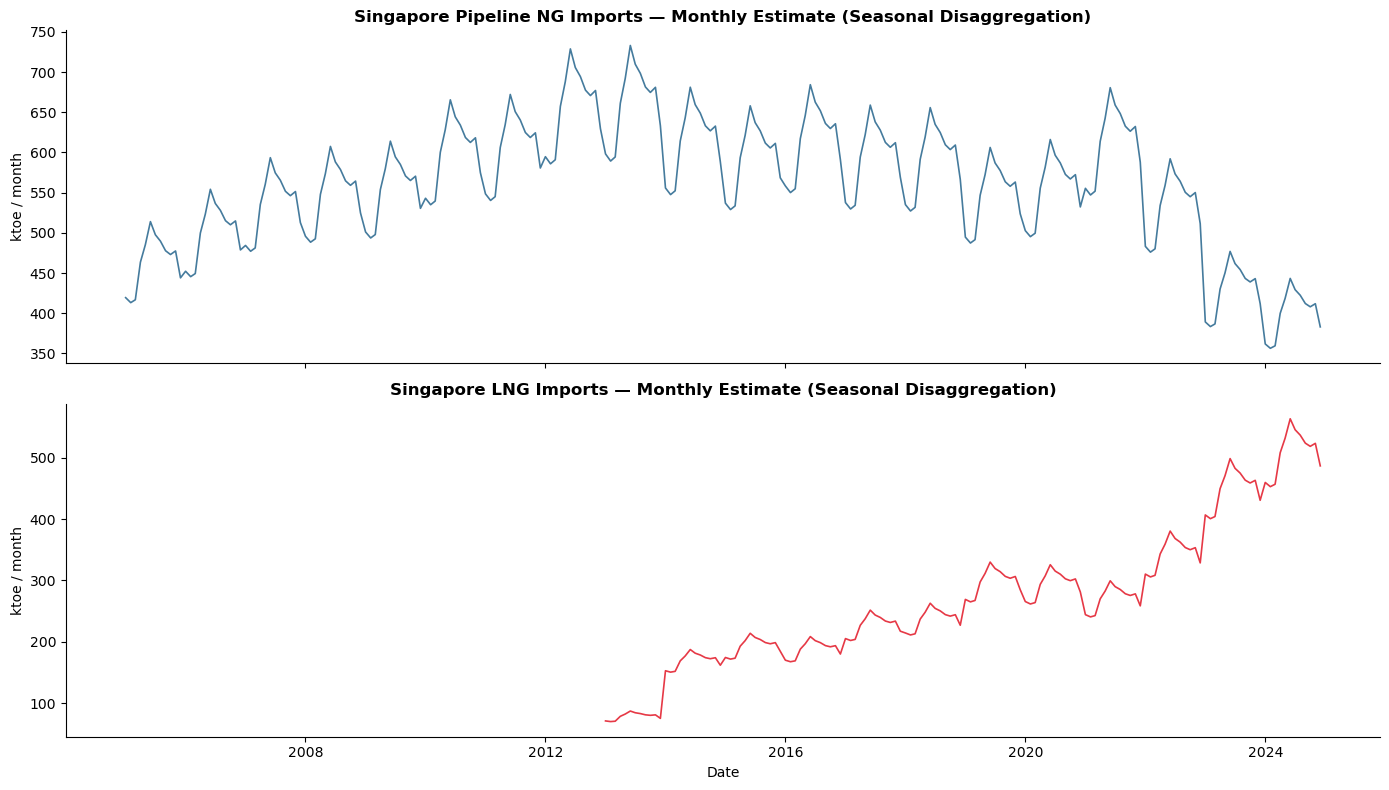

✅ Chart saved


In [31]:
# ── Step 5: Plot to confirm seasonal pattern was applied ─────────────────────
import matplotlib.pyplot as plt
import os  # Added import for directory creation

# Create outputs directory if it doesn't exist
os.makedirs('outputs', exist_ok=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# PNG — should show gentle seasonal waves on a declining trend (2017 onwards)
axes[0].plot(png_monthly.index, png_monthly['png_import_ktoe'],
             color='#457b9d', linewidth=1.2)
axes[0].set_title('Singapore Pipeline NG Imports — Monthly Estimate (Seasonal Disaggregation)',
                  fontweight='bold')
axes[0].set_ylabel('ktoe / month')

# LNG — should show near-zero until 2013, then rising with seasonal waves
axes[1].plot(lng_monthly.index, lng_monthly['lng_import_ktoe'],
             color='#e63946', linewidth=1.2)
axes[1].set_title('Singapore LNG Imports — Monthly Estimate (Seasonal Disaggregation)',
                  fontweight='bold')
axes[1].set_ylabel('ktoe / month')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('outputs/gas_imports_monthly_disaggregated.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")

In [32]:
# ── Step 6: Merge into master ─────────────────────────────────────────────────

# Combine PNG and LNG into one gas_imports DataFrame
gas_imports_monthly = pd.concat([png_monthly, lng_monthly], axis=1)

# Fill LNG zeros for pre-2013 (terminal didn't exist, value is correctly 0)
gas_imports_monthly['lng_import_ktoe'] = \
    gas_imports_monthly['lng_import_ktoe'].fillna(0)

# Initialize master DataFrame if it doesn't exist
# You can either create an empty DataFrame or use gas_imports_monthly as the starting point
try:
    # Try to use existing master DataFrame
    master = pd.concat([master, gas_imports_monthly], axis=1, join='outer')
except NameError:
    # If master doesn't exist, create it with gas_imports_monthly
    master = gas_imports_monthly.copy()
    print("Created new master DataFrame")

print("=== UPDATED MASTER ===")
print("Shape:", master.shape)
print("Columns:", master.columns.tolist())
print("\nMissing values:")
print(master.isnull().sum())

Created new master DataFrame
=== UPDATED MASTER ===
Shape: (240, 2)
Columns: ['png_import_ktoe', 'lng_import_ktoe']

Missing values:
png_import_ktoe    0
lng_import_ktoe    0
dtype: int64


### Singapore Gas Import Volumes (EMA / SES_tabular)
- **Source:** Energy Market Authority, Singapore Energy Statistics Table
- **URL:** https://www.ema.gov.sg/resources/singapore-energy-statistics
- **Original frequency:** Annual (2005–2024), unit: ktoe
- **Variables:** Pipeline NG imports, Liquefied NG imports
- **Disaggregation method:** Annual totals distributed to monthly using
  seasonal weights derived from Singapore electricity consumption patterns.
  Monthly estimates re-aggregate exactly to annual source totals (verified).
- **Known limitations:** Monthly values are estimates, not measured data.
  Actual intra-year distribution may differ from weights used.
  LNG values before 2013 are zero — SLNG terminal opened in 2013.

# Combining All Files Into One Master DataFrame

In [33]:
# ── PRE-CHECK: Confirm all 6 DataFrames are in memory ────────────────────────
# Run this first. If any name throws a NameError, go back and run that
# file's loading cell before proceeding.

dataframes = {
    'jkm':         jkm,
    'henry':       henry,
    'ttf':         ttf,
    'usep':        usep,
    'png_monthly': png_monthly,
    'lng_monthly': lng_monthly
}

for name, df in dataframes.items():
    print(f"{name:15s} | shape: {str(df.shape):12s} | "
          f"index type: {type(df.index).__name__:20s} | "
          f"from {df.index.min().date()} to {df.index.max().date()}")

jkm             | shape: (411, 1)     | index type: DatetimeIndex        | from 1992-01-01 to 2026-03-01
henry           | shape: (411, 1)     | index type: DatetimeIndex        | from 1992-01-01 to 2026-03-01
ttf             | shape: (411, 1)     | index type: DatetimeIndex        | from 1992-01-01 to 2026-03-01
usep            | shape: (256, 1)     | index type: DatetimeIndex        | from 2005-01-01 to 2026-04-01
png_monthly     | shape: (240, 1)     | index type: DatetimeIndex        | from 2005-01-01 to 2024-12-01
lng_monthly     | shape: (144, 1)     | index type: DatetimeIndex        | from 2013-01-01 to 2024-12-01


In [34]:
# ── MERGE ─────────────────────────────────────────────────────────────────────
master = pd.concat([
    jkm,           # col: jkm_price
    henry,         # col: henry_price
    ttf,           # col: ttf_price
    usep,          # col: usep_price
    png_monthly,   # col: png_import_ktoe
    lng_monthly,   # col: lng_import_ktoe
], axis=1, join='outer')

master.index.name = 'date'
master.index = pd.to_datetime(master.index)
master = master.sort_index()

print("=== MASTER AFTER MERGE ===")
print("Shape:", master.shape)
print("Columns:", master.columns.tolist())
print("\nDate range:", master.index.min().date(), "→", master.index.max().date())
print("\nMissing values (NaN is expected — different series have different start dates):")
print(master.isnull().sum())

=== MASTER AFTER MERGE ===
Shape: (412, 6)
Columns: ['jkm_price', 'henry_price', 'ttf_price', 'USEP', 'png_import_ktoe', 'lng_import_ktoe']

Date range: 1992-01-01 → 2026-04-01

Missing values (NaN is expected — different series have different start dates):
jkm_price            1
henry_price          1
ttf_price            1
USEP               156
png_import_ktoe    172
lng_import_ktoe    268
dtype: int64


In [35]:
# ── TRIM to analysis period ───────────────────────────────────────────────────
# 2005-01-01 is when the last series (USEP, PNG/LNG) begins
master = master.loc['2005-01-01':].copy()

print("=== MASTER AFTER TRIM ===")
print("Shape:", master.shape)
print("Date range:", master.index.min().date(), "→", master.index.max().date())
print("\nMissing values after trim:")
print(master.isnull().sum())

=== MASTER AFTER TRIM ===
Shape: (256, 6)
Date range: 2005-01-01 → 2026-04-01

Missing values after trim:
jkm_price            1
henry_price          1
ttf_price            1
USEP                 0
png_import_ktoe     16
lng_import_ktoe    112
dtype: int64


In [36]:
# ── FIX: LNG imports = 0 before SLNG terminal opened ─────────────────────────
master.loc[:'2012-12-01', 'lng_import_ktoe'] = 0.0

# Confirm — every value from 2005 to end-2012 must be exactly 0
pre_2013 = master.loc['2005-01-01':'2012-12-01', 'lng_import_ktoe']
print("LNG imports 2005–2012 (all must be 0.0):")
print(f"  Min: {pre_2013.min()}  Max: {pre_2013.max()}  "
      f"Nulls: {pre_2013.isnull().sum()}")

# Confirm — 2013 onwards must have positive values
post_2013 = master.loc['2013-01-01':, 'lng_import_ktoe']
print("\nLNG imports 2013 onwards (must be positive):")
print(f"  Min: {post_2013.min():.2f}  Max: {post_2013.max():.2f}  "
      f"Nulls: {post_2013.isnull().sum()}")

LNG imports 2005–2012 (all must be 0.0):
  Min: 0.0  Max: 0.0  Nulls: 0

LNG imports 2013 onwards (must be positive):
  Min: 70.32  Max: 563.16  Nulls: 16


In [37]:
# ── FILL: Price columns — forward fill only ───────────────────────────────────
price_cols = ['jkm_price', 'henry_price', 'ttf_price', 'USEP']

master[price_cols] = master[price_cols].ffill()

print("Missing values in price columns after forward fill:")
print(master[price_cols].isnull().sum())

Missing values in price columns after forward fill:
jkm_price      0
henry_price    0
ttf_price      0
USEP           0
dtype: int64


In [38]:
# ── FILL: PNG imports — forward fill only ─────────────────────────────────────
master['png_import_ktoe'] = master['png_import_ktoe'].ffill()

print("Missing values in png_import_ktoe after fill:",
      master['png_import_ktoe'].isnull().sum())

Missing values in png_import_ktoe after fill: 0


In [39]:
# ── FILL: PNG imports — forward fill only ─────────────────────────────────────
master['png_import_ktoe'] = master['png_import_ktoe'].ffill()

print("Missing values in png_import_ktoe after fill:",
      master['png_import_ktoe'].isnull().sum())

Missing values in png_import_ktoe after fill: 0


In [40]:
# ── FINAL QUALITY CHECK ───────────────────────────────────────────────────────
print("=" * 50)
print("MASTER DATAFRAME — FINAL STATE")
print("=" * 50)
print(f"Shape:       {master.shape}")
print(f"Date range:  {master.index.min().date()} → {master.index.max().date()}")
print(f"Columns:     {master.columns.tolist()}")

print("\n--- Missing Values (should all be 0) ---")
print(master.isnull().sum())

print("\n--- Descriptive Statistics ---")
print(master.describe().round(2))

print("\n--- First 3 rows ---")
print(master.head(3))

print("\n--- Last 3 rows ---")
print(master.tail(3))

print("\n--- LNG import check (2012 vs 2013) ---")
print(master.loc['2012-10-01':'2013-06-01', 'lng_import_ktoe'])

MASTER DATAFRAME — FINAL STATE
Shape:       (256, 6)
Date range:  2005-01-01 → 2026-04-01
Columns:     ['jkm_price', 'henry_price', 'ttf_price', 'USEP', 'png_import_ktoe', 'lng_import_ktoe']

--- Missing Values (should all be 0) ---
jkm_price           0
henry_price         0
ttf_price           0
USEP                0
png_import_ktoe     0
lng_import_ktoe    16
dtype: int64

--- Descriptive Statistics ---
       jkm_price  henry_price  ttf_price    USEP  png_import_ktoe  \
count     256.00       256.00     256.00  256.00           256.00   
mean       12.17         4.25      10.48  148.92           550.56   
std         7.16         2.23       7.90   75.62            87.86   
min         2.03         1.70       1.46   43.60           356.29   
25%         7.77         2.76       6.48   98.48           493.34   
50%        10.04         3.48       8.65  132.85           561.75   
75%        15.71         5.00      11.44  183.35           617.47   
max        54.16        13.63      69.

In [41]:
# ── SAVE ──────────────────────────────────────────────────────────────────────
import os
os.makedirs('data/clean', exist_ok=True)

master.to_csv('data/clean/master_raw.csv', encoding='utf-8')

print("✅ Saved: data/clean/master_raw.csv")
print(f"   {master.shape[0]} rows × {master.shape[1]} columns")
print(f"   {master.index.min().date()} → {master.index.max().date()}")

✅ Saved: data/clean/master_raw.csv
   256 rows × 6 columns
   2005-01-01 → 2026-04-01


# Replace EMA Import data with Trade Maps Data

In [42]:
# ── Load Trade Map combined gas imports file ──────────────────────────────────
tm_raw = pd.read_csv(
    'SG LNG and gas imports.csv',
    skiprows=1,                  # Skip the "Tons, Tons" unit header row
    names=['date', 'lng_import_tonnes', 'png_import_tonnes'],
    encoding='utf-8-sig'
)

print("Raw shape:", tm_raw.shape)
print("\nFirst 5 rows:")
print(tm_raw.head())
print("\nLast 5 rows:")
print(tm_raw.tail())

Raw shape: (199, 3)

First 5 rows:
     date lng_import_tonnes png_import_tonnes
0    Date       LNG Imports  Pipeline Imports
1  Jan-11                 1            523246
2  Feb-11              1000            530407
3  Mar-11                 2            476572
4  Apr-11               699            535119

Last 5 rows:
    date lng_import_tonnes png_import_tonnes
194  NaN               NaN               NaN
195  NaN               NaN               NaN
196  NaN               NaN               NaN
197  NaN               NaN               NaN
198  NaN               NaN               NaN


### Gas Import Volumes (PNG and LNG)
- **Source:** ITC Trade Map, HS 271111 (LNG) and HS 270821 (PNG)
- **Unit:** Metric tonnes (no conversion applied — both from same source)
- **Coverage:** Monthly, 2005 – [latest month in file]
- **LNG pre-May 2013:** Set to 0.0 (SLNG terminal not yet operational)
- **Advantage over EMA:** Monthly observed values vs annual + seasonal disaggregation
- **Limitation:** Customs declaration date may lag actual cargo discharge by 1–2 months

In [43]:
# ── Step 1: Parse 'Jan-11' → 2011-01-01 ──────────────────────────────────────
# First, ensure tm_raw is defined (you need to load your data first)
# tm_raw = pd.read_csv('your_file.csv')  # Add this line to load your data

tm_raw['date'] = pd.to_datetime(
    tm_raw['date'].astype(str).str.strip(),
    format='%b-%y',
    errors='coerce'
)

# ── Step 2: Drop rows where date failed to parse ──────────────────────────────
# These come from the trailing empty rows (,,) at the bottom of the CSV
print(f"Rows before dropping NaT: {len(tm_raw)}")
tm_raw = tm_raw.dropna(subset=['date'])  # Clean tm_raw first
print(f"Rows after dropping NaT:  {len(tm_raw)}")

# ── Step 3: Ensure numeric types ──────────────────────────────────────────────
tm_raw['lng_import_tonnes'] = pd.to_numeric(tm_raw['lng_import_tonnes'], errors='coerce')
tm_raw['png_import_tonnes'] = pd.to_numeric(tm_raw['png_import_tonnes'], errors='coerce')

# ── Step 4: Set date as index and sort ────────────────────────────────────────
tm = tm_raw.set_index('date').sort_index()  # Now create tm from cleaned tm_raw

# Remove Apr 2026 — incomplete month, only partial data available
tm = tm[tm.index != pd.Timestamp('2026-04-01')]

# ── Step 5: Confirm clean index ───────────────────────────────────────────────
print(f"Date range: {tm.index.min().date()} → {tm.index.max().date()}")
print(f"Total months: {len(tm)}")   # Should now be 182 (Mar 2026 is last)
print(f"Monotonic ascending: {tm.index.is_monotonic_increasing}")
print(f"NaT in index: {tm.index.isna().sum()}")
print(f"Missing LNG: {tm['lng_import_tonnes'].isna().sum()}")
print(f"Missing PNG: {tm['png_import_tonnes'].isna().sum()}")

Rows before dropping NaT: 199
Rows after dropping NaT:  183
Date range: 2011-01-01 → 2026-03-01
Total months: 183
Monotonic ascending: True
NaT in index: 0
Missing LNG: 0
Missing PNG: 0


In [52]:
# Check Data

print("=== MISSING VALUES ===")
print(tm.isnull().sum())

print("\n=== LNG IMPORTS: Annual totals (tonnes) ===")
lng_annual = (tm['lng_import_tonnes'].resample('YE').sum() / 1e6).round(3)
lng_annual.index = lng_annual.index.year
print(lng_annual.to_string(), "(million tonnes)")

print("\n=== PNG IMPORTS: Annual totals (tonnes) ===")
png_annual = (tm['png_import_tonnes'].resample('YE').sum() / 1e6).round(3)
png_annual.index = png_annual.index.year
print(png_annual.to_string(), "(million tonnes)")

print("\n=== OUTLIER CHECK: LNG monthly values > 800,000 tonnes ===")
outliers = tm[tm['lng_import_tonnes'] > 800_000]
print(outliers if len(outliers) > 0 else "None found")

=== MISSING VALUES ===
lng_import_tonnes    0
png_import_tonnes    0
lng_outlier_flag     0
total_gas_tonnes     0
lng_share            0
png_share            0
dtype: int64

=== LNG IMPORTS: Annual totals (tonnes) ===
date
2011    0.000
2012    0.000
2013    0.000
2014    1.942
2015    2.160
2016    2.265
2017    3.027
2018    3.216
2019    3.695
2020    4.213
2021    3.770
2022    3.926
2023    5.055
2024    6.781
2025    6.041
2026    1.186 (million tonnes)

=== PNG IMPORTS: Annual totals (tonnes) ===
date
2011    6.207
2012    7.577
2013    7.886
2014    7.224
2015    7.004
2016    7.245
2017    6.943
2018    6.899
2019    6.384
2020    6.582
2021    7.169
2022    6.429
2023    5.198
2024    4.739
2025    5.094
2026    1.328 (million tonnes)

=== OUTLIER CHECK: LNG monthly values > 800,000 tonnes ===
            lng_import_tonnes  png_import_tonnes  lng_outlier_flag  \
date                                                                 
2024-07-01            1291383             37

In [45]:
# ── Sanity check before applying any rules ────────────────────────────────────
print("=== LNG Annual Totals (million tonnes) ===")
lng_annual = (tm['lng_import_tonnes'].resample('YE').sum() / 1e6).round(3)
lng_annual.index = lng_annual.index.year
print(lng_annual.to_string())

print("\n=== PNG Annual Totals (million tonnes) ===")
png_annual = (tm['png_import_tonnes'].resample('YE').sum() / 1e6).round(3)
png_annual.index = png_annual.index.year
print(png_annual.to_string())

print("\n=== Outlier Check: LNG months > 800,000 tonnes ===")
outliers = tm[tm['lng_import_tonnes'] > 800_000]
if len(outliers) > 0:
    print(outliers[['lng_import_tonnes']])
else:
    print("None found")

=== LNG Annual Totals (million tonnes) ===
date
2011    0.015
2012    0.010
2013    0.102
2014    1.942
2015    2.160
2016    2.265
2017    3.027
2018    3.216
2019    3.695
2020    4.213
2021    3.770
2022    3.926
2023    5.055
2024    6.781
2025    6.041
2026    1.186

=== PNG Annual Totals (million tonnes) ===
date
2011    6.207
2012    7.577
2013    7.886
2014    7.224
2015    7.004
2016    7.245
2017    6.943
2018    6.899
2019    6.384
2020    6.582
2021    7.169
2022    6.429
2023    5.198
2024    4.739
2025    5.094
2026    1.328

=== Outlier Check: LNG months > 800,000 tonnes ===
            lng_import_tonnes
date                         
2024-07-01            1291383


In [46]:
# ── Rule 1: Set LNG = 0 before 2014 ──────────────────────────────────────────
# SLNG terminal opened May 2013 but first full commercial month = Jan 2014
# Small values (0–3,056 tonnes) in 2011–2013 are test cargoes / data noise
tm.loc[tm.index < '2014-01-01', 'lng_import_tonnes'] = 0.0

print("LNG transition 2013→2014 (all pre-2014 must be 0):")
print(tm.loc['2013-09-01':'2014-04-01', 'lng_import_tonnes'].to_string())

# ── Rule 2: Flag Jul 2024 outlier ────────────────────────────────────────────
# 1,291,383 tonnes ≈ 3× monthly average — likely re-export or data error
# Do NOT delete — flag for transparency and investigate before modelling
tm['lng_outlier_flag'] = 0

jul2024 = pd.Timestamp('2024-07-01')
if jul2024 in tm.index:
    tm.loc[jul2024, 'lng_outlier_flag'] = 1
    print("\n⚠️  Jul 2024 LNG flagged:")
    print(tm.loc['2024-05-01':'2024-09-01',
                 ['lng_import_tonnes', 'lng_outlier_flag']].to_string())

LNG transition 2013→2014 (all pre-2014 must be 0):
date
2013-09-01         0
2013-10-01         0
2013-11-01         0
2013-12-01         0
2014-01-01    162803
2014-02-01    135091
2014-03-01    131528
2014-04-01    200664

⚠️  Jul 2024 LNG flagged:
            lng_import_tonnes  lng_outlier_flag
date                                           
2024-05-01             560828                 0
2024-06-01             518449                 0
2024-07-01            1291383                 1
2024-08-01             442466                 0
2024-09-01             453276                 0


In [47]:
# ── Sort the datetime index to ensure monotonic ordering ──────────────────────
tm = tm.sort_index()  # This ensures the DatetimeIndex is monotonic

# ── Domain rule: LNG noise values before 2014 → set to 0 ─────────────────────
# SLNG terminal opened May 2013, but first FULL commercial month = Jan 2014
# Values of 0–3,056 tonnes in 2011–2013 are noise (test cargoes / data artefacts)
# From Jan 2014 onwards, values are genuine commercial LNG imports

tm.loc[tm.index < '2014-01-01', 'lng_import_tonnes'] = 0.0   # ← NEW — correct

print("LNG 2011–2014 transition (pre-2014 should all be 0):")
print(tm.loc['2013-06-01':'2014-06-01', 'lng_import_tonnes'].to_string())

# ── Flag Jul 2024 outlier — do NOT delete, flag for transparency ──────────────
tm['lng_outlier_flag'] = 0
tm.loc['2024-07-01', 'lng_outlier_flag'] = 1   # 1.29M tonnes — investigate

print("\n⚠️  Jul 2024 LNG flagged as potential outlier:")
print(tm.loc['2024-06-01':'2024-09-01',
             ['lng_import_tonnes', 'lng_outlier_flag']].to_string())

LNG 2011–2014 transition (pre-2014 should all be 0):
date
2013-06-01         0
2013-07-01         0
2013-08-01         0
2013-09-01         0
2013-10-01         0
2013-11-01         0
2013-12-01         0
2014-01-01    162803
2014-02-01    135091
2014-03-01    131528
2014-04-01    200664
2014-05-01    134405
2014-06-01    197709

⚠️  Jul 2024 LNG flagged as potential outlier:
            lng_import_tonnes  lng_outlier_flag
date                                           
2024-06-01             518449                 0
2024-07-01            1291383                 1
2024-08-01             442466                 0
2024-09-01             453276                 0


In [48]:
# ── Calculate total gas supply and LNG market share ───────────────────────────
tm['total_gas_tonnes'] = tm['lng_import_tonnes'] + tm['png_import_tonnes']
tm['lng_share']        = (tm['lng_import_tonnes'] / tm['total_gas_tonnes']).round(4)
tm['png_share']        = (tm['png_import_tonnes'] / tm['total_gas_tonnes']).round(4)

# ── Fuel switch trend ─────────────────────────────────────────────────────────
print("=== Annual LNG Share (fuel switch progression) ===")
annual_share = tm['lng_share'].resample('YE').mean().round(3)
annual_share.index = annual_share.index.year
print(annual_share.to_string())

print("\nSample recent months (last 12):")
print(tm[['lng_import_tonnes', 'png_import_tonnes',
          'total_gas_tonnes', 'lng_share']].tail(12).to_string())

=== Annual LNG Share (fuel switch progression) ===
date
2011    0.000
2012    0.000
2013    0.000
2014    0.210
2015    0.233
2016    0.234
2017    0.301
2018    0.314
2019    0.363
2020    0.386
2021    0.340
2022    0.374
2023    0.490
2024    0.574
2025    0.539
2026    0.465

Sample recent months (last 12):
            lng_import_tonnes  png_import_tonnes  total_gas_tonnes  lng_share
date                                                                         
2025-04-01             518276             412700            930976     0.5567
2025-05-01             334275             405377            739652     0.4519
2025-06-01             593747             436378           1030125     0.5764
2025-07-01             558070             438941            997011     0.5597
2025-08-01             487635             442957            930592     0.5240
2025-09-01             519915             429768            949683     0.5475
2025-10-01             577725             420957            998

In [49]:
# ── Drop old EMA-estimated columns from master if they exist ──────────────────
old_cols = ['lng_import_ktoe', 'png_import_ktoe',
            'lng_import_tonnes', 'png_import_tonnes',
            'total_gas_tonnes', 'lng_share', 'png_share', 'lng_outlier_flag']

cols_to_drop = [c for c in old_cols if c in master.columns]
if cols_to_drop:
    master = master.drop(columns=cols_to_drop)
    print(f"Dropped old columns: {cols_to_drop}")
else:
    print("No old gas import columns found — proceeding with join")

# ── Join Trade Map data onto master ───────────────────────────────────────────
# left join: keeps all master dates, fills NaN where Trade Map has no data
master = master.join(tm, how='left')

print("\n=== MASTER AFTER REPLACEMENT ===")
print("Shape:", master.shape)
print("Columns:", master.columns.tolist())

Dropped old columns: ['lng_import_ktoe', 'png_import_ktoe']

=== MASTER AFTER REPLACEMENT ===
Shape: (256, 10)
Columns: ['jkm_price', 'henry_price', 'ttf_price', 'USEP', 'lng_import_tonnes', 'png_import_tonnes', 'lng_outlier_flag', 'total_gas_tonnes', 'lng_share', 'png_share']


In [50]:
# ── Confirm master is clean before saving ─────────────────────────────────────
print("=== Missing Values ===")
print(master.isnull().sum())

print("\n=== Date Range ===")
print(f"{master.index.min().date()} → {master.index.max().date()}")

print("\n=== LNG zero rule (pre-2014 must all be 0) ===")
pre2014_max = master.loc[master.index < '2014-01-01', 'lng_import_tonnes'].max()
print(f"Max LNG value before 2014: {pre2014_max}  (must be 0.0)")

print("\n=== Sample: 2014 first full LNG year ===")
print(master.loc['2014-01-01':'2014-06-01',
                 ['lng_import_tonnes', 'png_import_tonnes', 'lng_share']].to_string())

print("\n=== Sample: most recent 6 months ===")
print(master[['lng_import_tonnes', 'png_import_tonnes',
              'lng_share']].tail(6).to_string())

=== Missing Values ===
jkm_price             0
henry_price           0
ttf_price             0
USEP                  0
lng_import_tonnes    73
png_import_tonnes    73
lng_outlier_flag     73
total_gas_tonnes     73
lng_share            73
png_share            73
dtype: int64

=== Date Range ===
2005-01-01 → 2026-04-01

=== LNG zero rule (pre-2014 must all be 0) ===
Max LNG value before 2014: 0.0  (must be 0.0)

=== Sample: 2014 first full LNG year ===
            lng_import_tonnes  png_import_tonnes  lng_share
date                                                       
2014-01-01           162803.0           610376.0     0.2106
2014-02-01           135091.0           597375.0     0.1844
2014-03-01           131528.0           554701.0     0.1917
2014-04-01           200664.0           609905.0     0.2476
2014-05-01           134405.0           566319.0     0.1918
2014-06-01           197709.0           603396.0     0.2468

=== Sample: most recent 6 months ===
            lng_import_ton

In [51]:
# ── Save master and standalone gas import file ────────────────────────────────
os.makedirs('data/clean', exist_ok=True)

master.to_csv('data/clean/master_raw.csv', encoding='utf-8')
tm.to_csv('data/clean/gas_imports_trademap.csv', encoding='utf-8')

print("✅ Saved: data/clean/master_raw.csv")
print(f"   Shape: {master.shape}")
print(f"   Date range: {master.index.min().date()} → {master.index.max().date()}")

print("\n✅ Saved: data/clean/gas_imports_trademap.csv")
print(f"   Shape: {tm.shape}")
print(f"   Columns: {tm.columns.tolist()}")

✅ Saved: data/clean/master_raw.csv
   Shape: (256, 10)
   Date range: 2005-01-01 → 2026-04-01

✅ Saved: data/clean/gas_imports_trademap.csv
   Shape: (183, 6)
   Columns: ['lng_import_tonnes', 'png_import_tonnes', 'lng_outlier_flag', 'total_gas_tonnes', 'lng_share', 'png_share']


In [53]:
# Overwrite saved files with Apr 2026 removed
tm.to_csv('data/clean/gas_imports_trademap.csv', encoding='utf-8')
master.to_csv('data/clean/master_raw.csv', encoding='utf-8')
master.to_csv('data/clean/master_eda.csv', encoding='utf-8')

print("✅ All files updated — Apr 2026 removed")

✅ All files updated — Apr 2026 removed
